In [1]:
%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=-1

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

try:
    print(jax.devices())
except:
    print(jax.devices())

env: JAX_PLATFORM=cpu
env: CUDA_VISIBLE_DEVICES=-1
[CpuDevice(id=0)]


2024-10-28 00:18:31.912510: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
from simulator import Simulator
from systems import ToyExample

import jax.numpy as jnp
import jax.random as jr

sim = Simulator(ToyExample(), mpc_horizon=10, Jy=1.0, Ju=0.1, Q=0.1, R=0.1, key=jr.key(0))
y_ref = jnp.ones((100, 1))
u_ref = jnp.ones((100, 1))
x_ref = jnp.zeros((100, 2))
res = sim.rollout(y_ref, u_ref, x_ref, key=jr.key(0))

In [3]:
sim.policy.loss(res)

Array(3591.5618, dtype=float32)

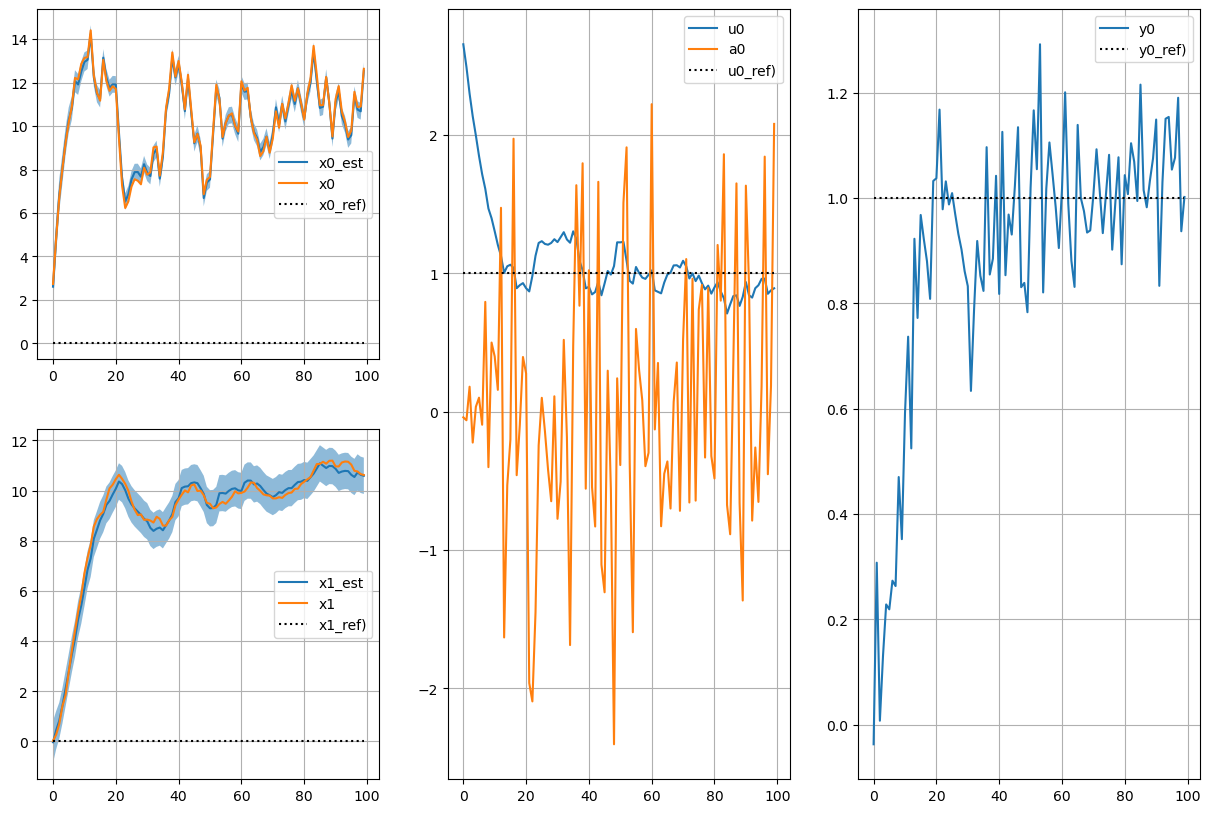

In [4]:
plt.figure(figsize=(15, 10))
for i in range(res.x.shape[-1]):
    plt.subplot(res.x.shape[-1], 3, 3*i + 1)
    mu, cov = res.est.mean[:, i], res.est.cov[:, i, i]
    plt.plot(mu, label=f"x{i}_est")
    plt.fill_between(range(len(mu)), mu - cov, mu + cov, alpha=0.5)
    plt.plot(res.x[:, i], label=f"x{i}")
    plt.plot(x_ref[:, i], ":k", label=f"x{i}_ref)")
    plt.legend()
    plt.grid()
for i in range(res.u.shape[-1]):
    plt.subplot(res.u.shape[-1], 3, 3*i + 2)
    plt.plot(res.u[:, i], label=f"u{i}")
    plt.plot(res.a[:, i], label=f"a{i}")        
    plt.plot(u_ref[:, i], ":k", label=f"u{i}_ref)")
    plt.legend()
    plt.grid()
for i in range(res.y.shape[-1]):
    plt.subplot(res.y.shape[-1], 3, 3*i + 3)
    plt.plot(res.y[:, i], label=f"y{i}")
    plt.plot(y_ref[:, i], ":k", label=f"y{i}_ref)")
    plt.legend()
    plt.grid()